# Chemprop

Kai Zhang, The University of Texas at Tyler

__References:__


GitHub repo https://github.com/chemprop/chemprop

Documentation https://chemprop.readthedocs.io/en/main/

App https://chemprop.com/


## 1. Installation

As of 2026.10, chemprop's dependency on Python version and numpy version can be tricky. It is better to use the recommended `conda` system to create a customized virtual environment. (Also check another notebook `0_intro_to_Python.ipynb`)

Install conda first if not done yet,
```
cd ~/Downloads
wget https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh
bash Miniconda3-latest-Linux-x86_64.sh
```
press some `Enter` and `yes`, which should put conda at
```
/home/your_username/miniconda3
```
Enable conda for the first time after installation
```
source ~/.bashrc
```
(or do it manually if not loaded on the terminal)
```
conda activate
```



Create a dedicated virtual environment for chemprop with a particular Python version, enable it and install chemprop
```
conda create -n chemprop python=3.11
conda activate chemprop
pip install chemprop
```
you may want to install Jupyter under this virtual environment as well (`pip install Jupyter`).

## 2. (Optional) Upgrade Nvidia GPU driver

In case Nvidia GPU driver is not compatible with PyTorch

```
nvidia-smi
sudo ubuntu-drivers list                  # check current available drivers
sudo apt install nvidia-driver-580-open   # install the proper version, say 580-open
sudo reboot
```

In [3]:
# check python version
!which python
!python --version

# show where chemprop package is installed
!pip show chemprop

import numpy as np
print('numpy version:', np.__version__)

import chemprop
print('chemprop version:', chemprop.__version__) # the latest version should be 2.x

import torch
print('PyTorch version:', torch.__version__)
print('CUDA build:', torch.version.cuda)
print('CUDA available:', torch.cuda.is_available())

# check GPU compatibility, might need to upgrade Nvidia driver for PyTorch
print('GPU:', torch.cuda.get_device_name(0))
print('Capability:', torch.cuda.get_device_capability(0))

/home/lambda2/miniconda3/envs/chemprop/bin/python
Python 3.11.17
Name: chemprop
Version: 2.3.1
Summary: Molecular Property Prediction with Message Passing Neural Networks
Home-page: 
Author: 
Author-email: "The Chemprop Development Team (see LICENSE.txt)" <chemprop@mit.edu>
License: MIT
Location: /home/lambda2/miniconda3/envs/chemprop/lib/python3.11/site-packages
Requires: astartes, ConfigArgParse, cuik_molmaker_pin, descriptastorus, lightning, myerson, numpy, pandas, rdkit, rich, scikit-learn, scipy, torch
Required-by: 
numpy version: 2.4.6
chemprop version: 2.3.1
PyTorch version: 2.14.1+cu130
CUDA build: 13.0
CUDA available: True
GPU: NVIDIA GeForce RTX 4090
Capability: (8, 9)


## 3. Run chemprop on Jupyter notebook for learning purpose

Let's first work through a simplest regression task on Jupyter notebook, step by step. Ultimately, it is more convenient to run chemprop in command line.

__References:__

https://chemprop.readthedocs.io/en/main/training.html

https://github.com/chemprop/chemprop-workshop-acs-fall2023/blob/main/chemprop_colab_demo_acs_fall2023.ipynb

Some commonly used chemprop Python modules are

* `chemprop.data`:
* `chemprop.featurizers`:
* `chemprop.models`:
* `chemprop.nn`:

See their tutorials at https://chemprop.readthedocs.io/en/main/tutorial/python/index.html .

You can also check the definition of a module or a function by, e.g.
```python
help(data)
help(data.make_split_indices)
```

In [16]:
# load certain Python packages
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.decomposition import PCA
from rdkit import Chem

In [13]:
# load chemprop functions
from chemprop import data, featurizers, models, nn

### 3.1 Load and preprocess the data

As an example, we use the log solubility regression dataset on chemprop https://github.com/chemprop/chemprop/blob/main/tests/data/regression.csv , which contains 500 data points.

In [12]:
data_path = '../datasets/chemprop/regression.csv' # use the correct file path and file name for your own case
df_input = pd.read_csv(data_path) # load example log solubility dataset
df_input

,smiles,logSolubility
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.770
1,Cc1occc1C(=O)Nc2ccccc2,-3.300
2,CC(C)=CCCC(C)=CC(=O),-2.060
3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.870
4,c1ccsc1,-1.330
...,...,...
495,Nc1cc(nc(N)n1=O)N2CCCCC2,-1.989
496,Nc2cccc3nc1ccccc1cc23,-4.220
497,c1ccc2cc3c4cccc5cccc(c3cc2c1)c45,-8.490
498,OC(c1ccc(Cl)cc1)(c2ccc(Cl)cc2)C(Cl)(Cl)Cl,-5.666


In [114]:
smiles = df_input.loc[:,'smiles'].values
logS = df_input.loc[:,['logSolubility']].values # important, use [' '] to force the y array to be 2D of shape (n_samples, 1) 
print(smiles[:5])
print(logS[:5])

<StringArray>
['OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)C(O)C3O',
                                'Cc1occc1C(=O)Nc2ccccc2',
                                  'CC(C)=CCCC(C)=CC(=O)',
                    'c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43',
                                               'c1ccsc1']
Length: 5, dtype: str
[[-0.77]
 [-3.3 ]
 [-2.06]
 [-7.87]
 [-1.33]]


### use `data.MoleculeDatapoint.from_smi()` to make a chemprop dataset object 

https://chemprop.readthedocs.io/en/main/tutorial/python/data/datapoints.html

In [115]:
# get molecule datapoints (x, y) in a list
all_data = [data.MoleculeDatapoint.from_smi(x, y) for x, y in zip(smiles, logS)]
print('number of datapoints:', len(all_data))
all_data[0] # show the content of the first datapoint

number of datapoints: 500


MoleculeDatapoint(mol=<rdkit.Chem.rdchem.Mol object at 0x727e09dd8c80>, y=array([-0.77]), weight=1.0, gt_mask=None, lt_mask=None, x_d=None, x_phase=None, name='OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)C(O)C3O', V_f=None, E_f=None, V_d=None)

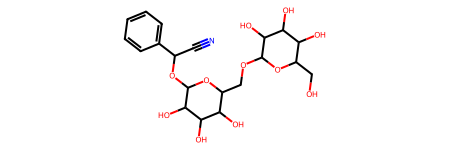

In [116]:
all_data[0].mol # show chemical structure with object .mol

In [117]:
print('name:', all_data[0].name, 'log S:', all_data[0].y)

name: OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)C(O)C3O log S: [-0.77]


### use `data.make_split_indices()` to divide all data into train, validation, test sets

https://chemprop.readthedocs.io/en/main/tutorial/python/data/splitting.html

Note that `data.make_split_indices()` puts training (or validation or test) data into a list of several replicates (by default only 1 replica). So we should use index 0 to access the first original copy. e.g. `train_data[0]`. 

In [118]:
mols = [d.mol for d in all_data]  # RDkit Mol objects are use for structure based splits
train_indices, val_indices, test_indices = data.make_split_indices(mols, "random", (0.8, 0.1, 0.1))  # unpack the tuple into three separate lists
train_data, val_data, test_data = data.split_data_by_indices(all_data, train_indices, val_indices, test_indices)
print(len(train_data[0]), len(val_data[0]), len(test_data[0]))

The return type of make_split_indices has changed in v2.1 - see help(make_split_indices)


400 50 50


### use `featurizers....` to create a feature vector for each molecule

The simplest featurizer, `SimpleMoleculeMolGraphFeaturizer()`, converts a `mol` to atom and bond type multi-hot vectors, returns a molecular graph `MolGraph` .

https://chemprop.readthedocs.io/en/main/tutorial/python/featurizers/molgraph_molecule_featurizer.html

`dset = data.MoleculeDataset()` makes a dataset using `MoleculeDatapoint` 's; 

`dset.data` is a list with length equal to the number of datapoints.

`dset.names` is a list of smiles strings

`dset.Y` is a list of y values, e.g. log S

When indexed, `dset[ ]` returns a `MolGraph` with atom and bond features, accessed by attribute `dset[].mg`. The MolGraphs are generated as needed by default. 

https://chemprop.readthedocs.io/en/main/tutorial/python/data/datasets.html

In [119]:
featurizer = featurizers.SimpleMoleculeMolGraphFeaturizer() # define the featurizer you want to use
train_dset = data.MoleculeDataset(train_data[0], featurizer)

print(len(train_dset.data))

print('MoleculeDataPoint:', train_dset.data[0]) # show the first datapoint

print('SMILES string:', train_dset.names[0])

print('y value:', train_dset.Y[0])

print('molecular graph feature vector:')
print(train_dset[0])

400
MoleculeDataPoint: MoleculeDatapoint(mol=<rdkit.Chem.rdchem.Mol object at 0x727e086b61f0>, y=array([-5.35]), weight=1.0, gt_mask=None, lt_mask=None, x_d=None, x_phase=None, name='CC(=O)OC3(CCC4C2C=C(C)C1=CC(=O)CCC1(C)C2CCC34C)C(C)=O', V_f=None, E_f=None, V_d=None)
SMILES string: CC(=O)OC3(CCC4C2C=C(C)C1=CC(=O)CCC1(C)C2CCC34C)C(C)=O
y value: [-5.35]
molecular graph feature vector:
Datum(mg=MolGraph(V=array([[0.     , 0.     , 0.     , ..., 0.     , 0.     , 0.12011],
       [0.     , 0.     , 0.     , ..., 0.     , 0.     , 0.12011],
       [0.     , 0.     , 0.     , ..., 0.     , 0.     , 0.15999],
       ...,
       [0.     , 0.     , 0.     , ..., 0.     , 0.     , 0.12011],
       [0.     , 0.     , 0.     , ..., 0.     , 0.     , 0.12011],
       [0.     , 0.     , 0.     , ..., 0.     , 0.     , 0.15999]],
      shape=(28, 72), dtype=float32), E=array([[0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
  

### scaling (normalizing) target values (y values)

- define scaler using training data

- apply scaler to validation data

- do not apply scaler to test data

https://chemprop.readthedocs.io/en/main/tutorial/python/scaling.html

In [124]:
scaler = train_dset.normalize_targets()

val_dset = data.MoleculeDataset(val_data[0], featurizer)
val_dset.normalize_targets(scaler)

test_dset = data.MoleculeDataset(test_data[0], featurizer)

### define data loaders

In [126]:
num_workers = 0 # number of workers for dataloader. 0 means using main process for data loading

train_loader = data.build_dataloader(train_dset, num_workers=num_workers)
val_loader = data.build_dataloader(val_dset, num_workers=num_workers, shuffle=False)
test_loader = data.build_dataloader(test_dset, num_workers=num_workers, shuffle=False)

### 3.2 Define Message-Passing Neural Network (MPNN) 

## The End